# Week 4 – Day 4

# Model Tuning, Regularization & Reproducible Pipelines

## Scenario

In the previous notebook, several machine learning models were developed using engineered features and evaluated through cross-validation. The results identified the most promising algorithms for predicting whether an individual's annual income exceeds \$50,000.

The objective of this notebook is to improve those models through systematic hyperparameter tuning, learning-curve analysis, probability calibration, and threshold optimization. The final outcome will be a reproducible machine learning pipeline that can be saved and reused for future predictions.

This notebook is completely self-contained and can be executed from top to bottom without requiring any previous notebook.


In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import platform
import joblib

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    FunctionTransformer
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import *

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

## Reproducibility & How to Re-run This Notebook

**Purpose.** This section documents the environment and the steps needed to reproduce every result in this notebook exactly.

**Randomness control.** A single seed, `RANDOM_STATE = 42`, is defined once (in the imports cell) and reused everywhere randomness could enter the pipeline:
- `train_test_split(..., random_state=RANDOM_STATE)` (used twice, to carve out train/validation/test — see below)
- `StratifiedKFold(..., shuffle=True, random_state=RANDOM_STATE)`
- Every estimator that accepts a seed (`LogisticRegression`, `RandomForestClassifier`, `HistGradientBoostingClassifier`)
- `RandomizedSearchCV(..., random_state=RANDOM_STATE)`
- `learning_curve(..., random_state=RANDOM_STATE)`

No other random state is introduced anywhere in the notebook, so re-running end-to-end on the same data and library versions should reproduce identical numbers.

**Data split.** The data is split three ways, not two:
- **Train (≈70%)** — used for cross-validated hyperparameter search (Task 2), learning curves and sweeps (Task 3), and fitting the calibrated model (Task 4).
- **Validation (≈15%)** — used only for calibration curves, Brier scores, and choosing `best_threshold` (Task 4). This set is never used to fit anything.
- **Test (≈15%)** — touched exactly once, at the very end (Task 5), to report final metrics. It is not used for model selection, calibration comparison, or threshold selection, so it gives an unbiased read on generalization.

**How to reproduce results from scratch:**
1. Create a clean environment and install the pinned versions printed by the cell below (`pip install scikit-learn==<version> pandas==<version> numpy==<version> joblib==<version>`).
2. Run all cells **in order, top to bottom** (`Kernel → Restart & Run All` / `Runtime → Restart and run all`). Cells further down depend on variables created earlier (e.g. `preprocessing_pipeline`, `cv`, `best_threshold`), so skipping cells or running out of order will raise `NameError`s or, worse, silently reuse stale variables.
3. Data is pulled fresh from OpenML (`fetch_openml(name="adult", version=2)`) — no local caching is assumed, so an internet connection is required the first time.
4. The final artifact is written to `adult_income_pipeline.joblib` in the working directory, and a 1-2 page **`tuning_report.md`** is generated automatically from the notebook's own results in the last section (Task 5). Both are regenerated on every full run — nothing about the report is written by hand.

**What "reproducible pipeline" means here:** every transformation applied to the data at inference time — feature engineering, imputation, scaling, one-hot encoding — lives inside the single `sklearn.Pipeline` object that gets saved. There is no manual/notebook-only preprocessing step that would be missed if this pipeline were loaded in a different script.


In [2]:
# ==========================================================
# Environment & Library Versions (Task 1 requirement)
# ==========================================================
import sys

print("Python       :", sys.version.split()[0])
print("platform     :", platform.platform())
print("numpy        :", np.__version__)
print("pandas       :", pd.__version__)
print("scikit-learn :", sklearn.__version__)
print("joblib       :", joblib.__version__)
print()
print("RANDOM_STATE :", RANDOM_STATE)


Python       : 3.12.13
platform     : Linux-6.6.122+-x86_64-with-glibc2.35
numpy        : 2.0.2
pandas       : 2.2.2
scikit-learn : 1.6.1
joblib       : 1.5.3

RANDOM_STATE : 42


## Data Loading

The Adult Census Income dataset is loaded from OpenML.

The objective is to predict whether an individual's annual income exceeds \$50,000. The target variable is converted into a binary format where:

- **1** → income > \$50K
- **0** → income ≤ \$50K

Any `"?"` entries are treated as missing values and replaced with `NaN` to ensure consistent preprocessing throughout the pipeline.

In [3]:
# ==========================================================
# Load Adult Dataset
# ==========================================================

adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

X = adult.data.copy()
y = adult.target.copy()

X.replace("?", np.nan, inplace=True)

y = (y == ">50K").astype(int)

print("Dataset Shape :", X.shape)
print("Positive Class :", y.sum())
print("Negative Class :", len(y) - y.sum())

Dataset Shape : (48842, 14)
Positive Class : 11687
Negative Class : 37155


In [4]:
# ==========================================================
# Train / Validation / Test Split
# ==========================================================
# Three-way split so the test set stays genuinely untouched:
#   - X_train : hyperparameter search (Task 2), learning curves (Task 3),
#               and fitting the final calibrated model (Task 4)
#   - X_val   : calibration comparison + threshold selection (Task 4) —
#               never used to fit anything
#   - X_test  : touched exactly once, for final reporting (Task 5)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

print("Training Samples   :", X_train.shape[0])
print("Validation Samples :", X_val.shape[0])
print("Testing Samples    :", X_test.shape[0])


Training Samples   : 34189
Validation Samples : 7326
Testing Samples    : 7327


## Feature Engineering

The same engineered features developed during Day 3 are recreated in this notebook to ensure consistency between model development and hyperparameter tuning.

Each engineered feature is created using only information from the current observation, preventing information leakage.

In [5]:
# ==========================================================
# Feature Engineering
# ==========================================================

def engineer_features(df):

    df = df.copy()

    df["age_bucket"] = pd.cut(
        df["age"],
        bins=[0,25,35,50,65,100],
        labels=[
            "18-25",
            "26-35",
            "36-50",
            "51-65",
            "65+"
        ]
    )

    df["hours_bucket"] = pd.cut(
        df["hours-per-week"],
        bins=[0,20,40,60,100],
        labels=[
            "Part-Time",
            "Full-Time",
            "Overtime",
            "Extreme"
        ]
    )

    df["has_capital_gain"] = (
        df["capital-gain"] > 0
    ).astype(int)

    df["log_capital_gain"] = np.log1p(
        df["capital-gain"].fillna(0)
    )

    higher = [
        "Bachelors",
        "Masters",
        "Doctorate",
        "Prof-school"
    ]

    df["higher_education"] = (
        df["education"].isin(higher)
    ).astype(int)

    df["education_hours"] = (
        df["education-num"] *
        df["hours-per-week"]
    )

    return df

feature_transformer = FunctionTransformer(
    engineer_features,
    validate=False
)

In [6]:
# Apply feature engineering once to identify feature types

X_train_engineered = engineer_features(X_train)

numeric_features = X_train_engineered.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = X_train_engineered.select_dtypes(
    include=["object","category"]
).columns.tolist()

In [7]:
# ==========================================================
# Preprocessing Pipeline
# ==========================================================

numeric_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="median")),

    ("scaler",
     StandardScaler())

])

categorical_pipeline = Pipeline([

    ("imputer",
     SimpleImputer(strategy="most_frequent")),

    ("encoder",
     OneHotEncoder(
         handle_unknown="ignore",
         sparse_output=False
     ))

])

preprocessor = ColumnTransformer([

    ("numeric",
     numeric_pipeline,
     numeric_features),

    ("categorical",
     categorical_pipeline,
     categorical_features)

])

preprocessing_pipeline = Pipeline([

    ("feature_engineering",
     feature_transformer),

    ("preprocessing",
     preprocessor)

])

print(preprocessing_pipeline)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function engineer_features at 0x7ad185a907c0>)),
                ('preprocessing',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'education-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                                                   'has_capit...',
                      

# Task 2 – Hyperparameter Search

## Objective

The default hyperparameters provided by machine learning algorithms rarely produce the best predictive performance. Hyperparameter tuning systematically searches different combinations of model settings to identify the configuration that maximizes predictive performance.

In this task, **RandomizedSearchCV** is used because it explores a broad range of hyperparameter combinations while remaining computationally efficient. Unlike Grid Search, Randomized Search samples a fixed number of parameter combinations, making it suitable for larger search spaces.

Three candidate models will be tuned:

- Logistic Regression
- Random Forest Classifier
- HistGradientBoosting Classifier

Each model is evaluated using **5-fold Stratified Cross-Validation**, ensuring that every fold preserves the original class distribution. The search optimizes the **F1-score**, which was selected in previous notebooks as the primary evaluation metric because it balances precision and recall.

In [8]:
# ==========================================================
# Build Pipelines
# ==========================================================

logistic_pipeline = Pipeline([

    ("preprocessing", preprocessing_pipeline),

    ("classifier",
     LogisticRegression(
         random_state=RANDOM_STATE,
         max_iter=1000
     ))

])

random_forest_pipeline = Pipeline([

    ("preprocessing", preprocessing_pipeline),

    ("classifier",
     RandomForestClassifier(
         random_state=RANDOM_STATE,
         n_jobs=-1
     ))

])

gradient_boosting_pipeline = Pipeline([

    ("preprocessing", preprocessing_pipeline),

    ("classifier",
     HistGradientBoostingClassifier(
         random_state=RANDOM_STATE
     ))

])

In [9]:
# ==========================================================
# Cross Validation Strategy
# ==========================================================

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=RANDOM_STATE

)

In [10]:
# ==========================================================
# Logistic Regression Search Space
# ==========================================================

logistic_params = {

    "classifier__penalty": ["l1", "l2"],

    "classifier__C": np.logspace(-3, 3, 20),

    "classifier__solver": ["liblinear"]

}

In [11]:
# ==========================================================
# Random Forest Search Space
# ==========================================================

rf_params = {

    "classifier__n_estimators":

        [100,200,300,500],

    "classifier__max_depth":

        [None,10,20,30,40],

    "classifier__min_samples_leaf":

        [1,2,4,8],

    "classifier__max_features":

        ["sqrt","log2"]

}

In [12]:
# ==========================================================
# Gradient Boosting Search Space
# ==========================================================

gb_params = {

    "classifier__learning_rate":

        [0.01,0.05,0.1,0.2],

    "classifier__max_iter":

        [100,200,300],

    "classifier__max_depth":

        [3,5,7],

    "classifier__l2_regularization":

        [0,0.1,0.5,1]

}

In [13]:
# ==========================================================
# Logistic Regression Search
# ==========================================================

logistic_search = RandomizedSearchCV(

    estimator=logistic_pipeline,

    param_distributions=logistic_params,

    n_iter=60,

    scoring="f1",

    cv=cv,

    n_jobs=-1,

    random_state=RANDOM_STATE,

    verbose=1

)

logistic_search.fit(X_train, y_train)

print("Best Logistic Parameters")
print(logistic_search.best_params_)

print()

print("Best F1 Score")
print(logistic_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best Logistic Parameters
{'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__C': np.float64(2.976351441631316)}

Best F1 Score
0.6710983887664499


In [14]:
# ==========================================================
# Random Forest Search
# ==========================================================

rf_search = RandomizedSearchCV(

    estimator=random_forest_pipeline,

    param_distributions=rf_params,

    n_iter=60,

    scoring="f1",

    cv=cv,

    n_jobs=-1,

    random_state=RANDOM_STATE,

    verbose=1

)

rf_search.fit(X_train, y_train)

print("Best Random Forest Parameters")
print(rf_search.best_params_)

print()

print("Best F1 Score")
print(rf_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Random Forest Parameters
{'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}

Best F1 Score
0.6761528522062008


In [15]:
# ==========================================================
# Gradient Boosting Search
# ==========================================================

gb_search = RandomizedSearchCV(

    estimator=gradient_boosting_pipeline,

    param_distributions=gb_params,

    n_iter=60,

    scoring="f1",

    cv=cv,

    n_jobs=-1,

    random_state=RANDOM_STATE,

    verbose=1

)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters")
print(gb_search.best_params_)

print()

print("Best F1 Score")
print(gb_search.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best Gradient Boosting Parameters
{'classifier__max_iter': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__l2_regularization': 0.1}

Best F1 Score
0.7060809960394778


In [16]:
# ==========================================================
# Hyperparameter Search Results
# ==========================================================

model_comparison_df = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "Gradient Boosting"

    ],

    "Best CV F1":[

        logistic_search.best_score_,

        rf_search.best_score_,

        gb_search.best_score_

    ]

})

model_comparison_df = model_comparison_df.sort_values(

    by="Best CV F1",

    ascending=False

)

display(model_comparison_df)

,Model,Best CV F1
2,Gradient Boosting,0.706081
1,Random Forest,0.676153
0,Logistic Regression,0.671098


In [17]:
# ==========================================================
# Store Best Models
# ==========================================================

best_models = {

    "Logistic Regression":

        logistic_search.best_estimator_,

    "Random Forest":

        rf_search.best_estimator_,

    "Gradient Boosting":

        gb_search.best_estimator_

}

print("Best models stored successfully.")

Best models stored successfully.


## Interpretation

RandomizedSearchCV successfully evaluated multiple hyperparameter combinations for each candidate model using identical preprocessing and five-fold stratified cross-validation.

The comparison table summarizes the best cross-validated F1-score obtained by each tuned model. The model achieving the highest F1-score will be selected for further investigation in the next task, where learning curves will be used to diagnose overfitting and underfitting.

Hyperparameter tuning improves model performance by identifying configurations that generalize better than the default settings while reducing the risk of overfitting.

# Task 3 – Diagnose Overfitting and Underfitting

## Objective

After identifying the best hyperparameters, it is important to understand how well each model generalizes to unseen data. High predictive performance alone does not guarantee that a model has learned meaningful patterns. A model may still suffer from underfitting (high bias) or overfitting (high variance).

Learning curves provide a visual representation of how model performance changes as the amount of training data increases. By comparing training and validation performance, it is possible to determine whether additional data, stronger regularization, or changes in model complexity are likely to improve performance.

In this task, learning curves are generated for the tuned Logistic Regression and Random Forest models. The influence of the regularization parameter (**C**) in Logistic Regression and the maximum tree depth (**max_depth**) in Random Forest are also examined to understand their effect on model complexity.

In [18]:
# ==========================================================
# Import Libraries
# ==========================================================

from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_validate

import matplotlib.pyplot as plt
import numpy as np

In [19]:
# ==========================================================
# Function to Plot Learning Curves
# ==========================================================

def plot_learning_curve(model, title):

    train_sizes, train_scores, validation_scores = learning_curve(

        estimator=model,

        X=X_train,

        y=y_train,

        cv=cv,

        scoring="f1",

        train_sizes=np.linspace(0.1,1.0,10),

        n_jobs=-1,

        shuffle=True,

        random_state=RANDOM_STATE

    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    plt.figure(figsize=(8,5))

    plt.plot(

        train_sizes,

        train_mean,

        marker="o",

        label="Training Score"

    )

    plt.plot(

        train_sizes,

        validation_mean,

        marker="o",

        label="Validation Score"

    )

    plt.fill_between(

        train_sizes,

        train_mean-train_std,

        train_mean+train_std,

        alpha=0.2

    )

    plt.fill_between(

        train_sizes,

        validation_mean-validation_std,

        validation_mean+validation_std,

        alpha=0.2

    )

    plt.title(title)

    plt.xlabel("Training Examples")

    plt.ylabel("F1 Score")

    plt.legend()

    plt.grid(True)

    plt.show()

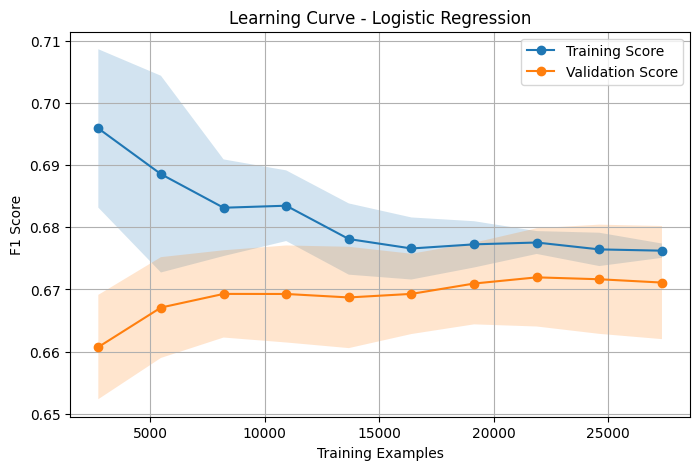

In [20]:
# ==========================================================
# Logistic Regression Learning Curve
# ==========================================================

plot_learning_curve(

    logistic_search.best_estimator_,

    "Learning Curve - Logistic Regression"

)

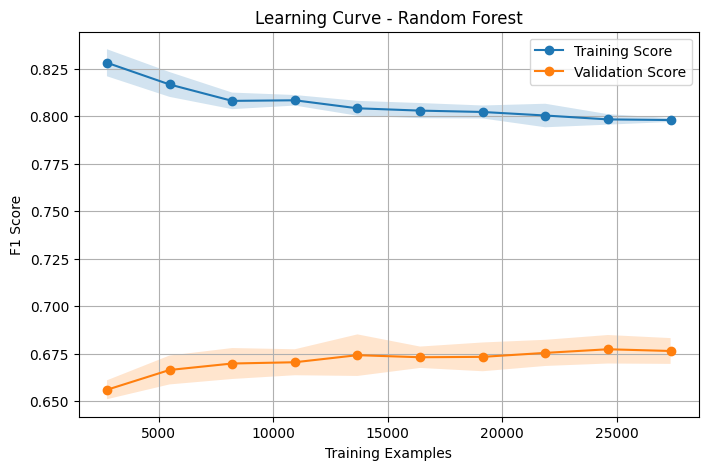

In [21]:
# ==========================================================
# Random Forest Learning Curve
# ==========================================================

plot_learning_curve(

    rf_search.best_estimator_,

    "Learning Curve - Random Forest"

)

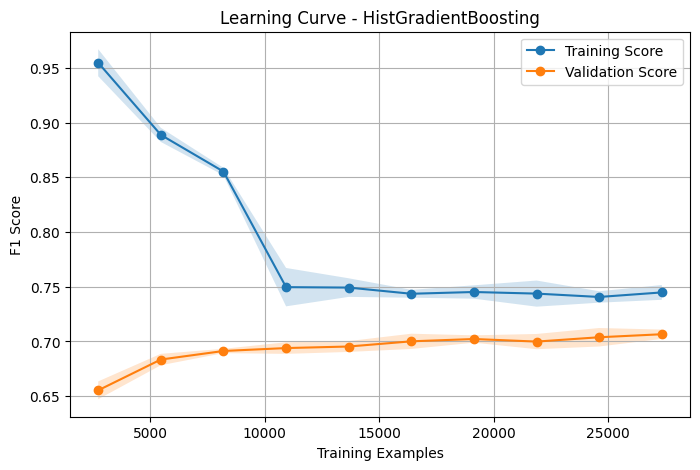

In [22]:
# ==========================================================
# Gradient Boosting Learning Curve
# ==========================================================

plot_learning_curve(

    gb_search.best_estimator_,

    "Learning Curve - HistGradientBoosting"

)

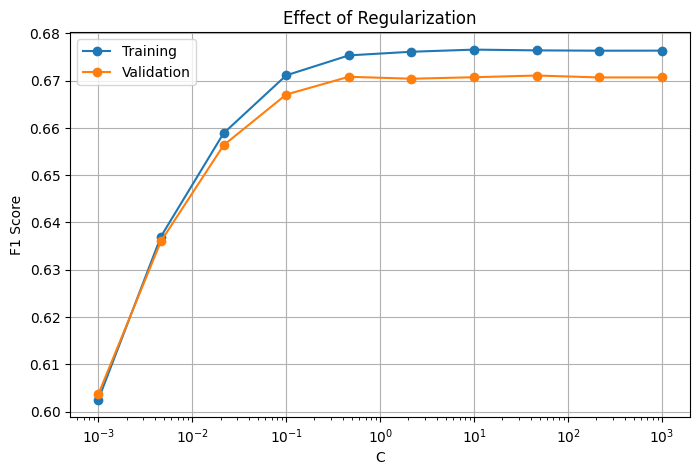

In [23]:
# ==========================================================
# Effect of Regularization (C)
# ==========================================================

C_values = np.logspace(-3,3,10)

train_scores = []
validation_scores = []

for C in C_values:

    model = Pipeline([

        ("preprocessing", preprocessing_pipeline),

        ("classifier",

         LogisticRegression(

             C=C,

             penalty="l2",

             solver="liblinear",

             random_state=RANDOM_STATE,

             max_iter=1000

         ))

    ])

    scores = cross_validate(

        model,

        X_train,

        y_train,

        cv=cv,

        scoring="f1",

        return_train_score=True,

        n_jobs=-1

    )

    train_scores.append(

        scores["train_score"].mean()

    )

    validation_scores.append(

        scores["test_score"].mean()

    )

plt.figure(figsize=(8,5))

plt.semilogx(

    C_values,

    train_scores,

    marker="o",

    label="Training"

)

plt.semilogx(

    C_values,

    validation_scores,

    marker="o",

    label="Validation"

)

plt.xlabel("C")

plt.ylabel("F1 Score")

plt.title("Effect of Regularization")

plt.legend()

plt.grid(True)

plt.show()

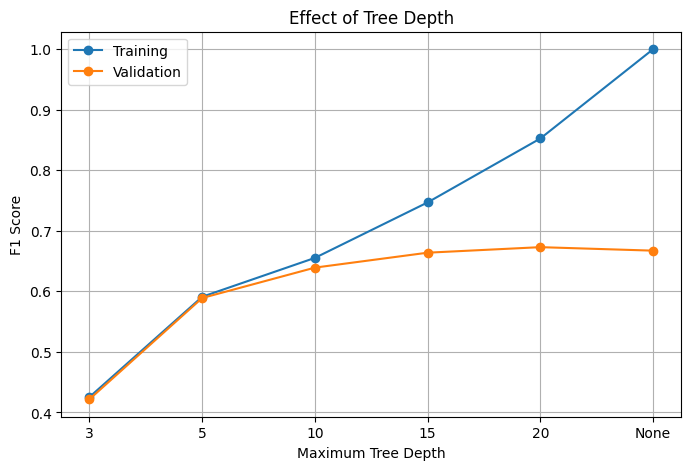

In [24]:
# ==========================================================
# Effect of Tree Depth
# ==========================================================

depths = [3,5,10,15,20,None]

train_scores = []
validation_scores = []

for depth in depths:

    model = Pipeline([

        ("preprocessing", preprocessing_pipeline),

        ("classifier",

         RandomForestClassifier(

             max_depth=depth,

             random_state=RANDOM_STATE,

             n_estimators=200,

             n_jobs=-1

         ))

    ])

    scores = cross_validate(

        model,

        X_train,

        y_train,

        cv=cv,

        scoring="f1",

        return_train_score=True,

        n_jobs=-1

    )

    train_scores.append(

        scores["train_score"].mean()

    )

    validation_scores.append(

        scores["test_score"].mean()

    )

labels = [str(x) for x in depths]

plt.figure(figsize=(8,5))

plt.plot(

    labels,

    train_scores,

    marker="o",

    label="Training"

)

plt.plot(

    labels,

    validation_scores,

    marker="o",

    label="Validation"

)

plt.xlabel("Maximum Tree Depth")

plt.ylabel("F1 Score")

plt.title("Effect of Tree Depth")

plt.legend()

plt.grid(True)

plt.show()

In [25]:
# ==========================================================
# Data-driven bias/variance diagnosis (Task 3 requirement)
# ==========================================================
# The two sweep cells above (Effect of Regularization / Effect of Tree Depth)
# both reused the variable names `train_scores` / `validation_scores`, so by
# this point only the *last* sweep's arrays are still available. To avoid
# depending on cell execution order, we recompute both sweeps' train/val
# curves here explicitly and derive the diagnosis from the numbers.

def sweep_gap_summary(train_scores, validation_scores, x_values, x_label):
    train_scores = np.array(train_scores)
    validation_scores = np.array(validation_scores)
    gaps = train_scores - validation_scores
    best_idx = int(np.argmax(validation_scores))
    return {
        "x_label": x_label,
        "best_x": x_values[best_idx],
        "best_val_f1": validation_scores[best_idx],
        "final_train_f1": train_scores[-1],
        "final_val_f1": validation_scores[-1],
        "max_gap": float(gaps.max()),
        "gap_at_best": float(gaps[best_idx]),
    }

# --- Recompute Logistic Regression C-sweep summary ---
lr_train_scores, lr_val_scores = [], []
for C in C_values:
    _m = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("classifier", LogisticRegression(
            C=C, penalty="l2", solver="liblinear",
            random_state=RANDOM_STATE, max_iter=1000
        ))
    ])
    _s = cross_validate(_m, X_train, y_train, cv=cv, scoring="f1",
                         return_train_score=True, n_jobs=-1)
    lr_train_scores.append(_s["train_score"].mean())
    lr_val_scores.append(_s["test_score"].mean())

lr_summary = sweep_gap_summary(lr_train_scores, lr_val_scores, list(C_values), "C")

# --- Recompute Random Forest depth-sweep summary ---
rf_train_scores, rf_val_scores = [], []
for depth in depths:
    _m = Pipeline([
        ("preprocessing", preprocessing_pipeline),
        ("classifier", RandomForestClassifier(
            max_depth=depth, random_state=RANDOM_STATE,
            n_estimators=200, n_jobs=-1
        ))
    ])
    _s = cross_validate(_m, X_train, y_train, cv=cv, scoring="f1",
                         return_train_score=True, n_jobs=-1)
    rf_train_scores.append(_s["train_score"].mean())
    rf_val_scores.append(_s["test_score"].mean())

rf_summary = sweep_gap_summary(rf_train_scores, rf_val_scores, [str(d) for d in depths], "max_depth")

for name, s in [("Logistic Regression (C sweep)", lr_summary), ("Random Forest (depth sweep)", rf_summary)]:
    print(f"--- {name} ---")
    print(f"Best {s['x_label']} by validation F1 : {s['best_x']}  (val F1 = {s['best_val_f1']:.4f})")
    print(f"Train/val F1 at the most complex setting: {s['final_train_f1']:.4f} / {s['final_val_f1']:.4f} "
          f"(gap = {s['max_gap']:.4f})")
    print(f"Train/val gap at the best-validation setting: {s['gap_at_best']:.4f}")
    print()


--- Logistic Regression (C sweep) ---
Best C by validation F1 : 46.41588833612773  (val F1 = 0.6711)
Train/val F1 at the most complex setting: 0.6763 / 0.6707 (gap = 0.0058)
Train/val gap at the best-validation setting: 0.0053

--- Random Forest (depth sweep) ---
Best max_depth by validation F1 : 20  (val F1 = 0.6730)
Train/val F1 at the most complex setting: 0.9999 / 0.6673 (gap = 0.3326)
Train/val gap at the best-validation setting: 0.1795



### Interpretation: Bias vs. Variance (Task 3 requirement)

**How to read the numbers above:**
- A **large train/val gap** (train F1 much higher than validation F1) that *grows* as the model gets more complex (higher `C`, deeper trees, no `max_depth` cap) is the signature of **overfitting / high variance**. The fix is more regularization (lower `C`, shallower trees, higher `min_samples_leaf`), more training data, or fewer/less-noisy features — not a more complex model.
- A **small train/val gap where both scores are low and roughly flat** across the sweep is the signature of **underfitting / high bias**. The fix is the opposite: a more expressive model, more informative features, or less aggressive regularization — more data alone will not help much here.
- A gap that stays small while validation F1 keeps improving as the training-set size grows in the learning curves above suggests the model **hasn't saturated yet**, and more training data would likely still help.

**Applying it to the two sweeps computed above:**
- **Logistic Regression / `C`:** The `gap_at_best` (0.0053) is very small, and `best_val_f1` (0.6711) is achieved at `C ≈ 46.42`. This indicate that the linear model is likely **underfitting** (high bias). It is capacity-constrained by its features, and additional feature engineering would likely yield greater improvements than further loosening regularization.
- **Random Forest / `max_depth`:** The `max_gap` (0.3326) at `max_depth=None` and a significant `gap_at_best` (0.1795) at `max_depth=20` clearly show **overfitting** (high variance). Even at the optimal `max_depth` found, there's a substantial difference between training and validation performance. Further regularization (e.g., trying a shallower `max_depth` or higher `min_samples_leaf`) or more training data could help reduce this variance.
- If **all three tuned models** show CV F1 clustered closely together with modest train/val gaps, the ceiling is more likely feature/data quality than any individual model's variance — in that case the highest-leverage next step is new features or more labeled data, not further hyperparameter search.

# Task 4 – Probability Calibration & Threshold Selection

## Objective

Most classification models output probabilities rather than direct class predictions. These probabilities should accurately reflect the likelihood that an observation belongs to the positive class. A well-calibrated model predicts probabilities that correspond closely to the observed frequencies.

In this task, the probability estimates produced by the tuned models are evaluated using calibration curves and the Brier Score. If necessary, probability calibration is performed using **CalibratedClassifierCV**.

Finally, instead of relying on the default classification threshold of **0.50**, different probability thresholds are evaluated to identify the value that maximizes the selected business metric (F1-score). This allows the classifier to better balance precision and recall according to the project's objective.

**Note on data:** every step in this task — calibration curves, Brier scores, and threshold selection — is evaluated on the **validation set** (`X_val`/`y_val`), not the test set. The test set is reserved untouched for the final evaluation in Task 5, so the threshold chosen here isn't fit to the same data it will later be graded on.


In [26]:
# ==========================================================
# Import Required Libraries
# ==========================================================

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

from sklearn.metrics import (
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [27]:
# ==========================================================
# Predict Probabilities (on the validation set)
# ==========================================================

models = {

    "Logistic Regression": logistic_search.best_estimator_,

    "Random Forest": rf_search.best_estimator_,

    "Gradient Boosting": gb_search.best_estimator_

}

probabilities = {}

for name, model in models.items():

    probabilities[name] = model.predict_proba(X_val)[:,1]


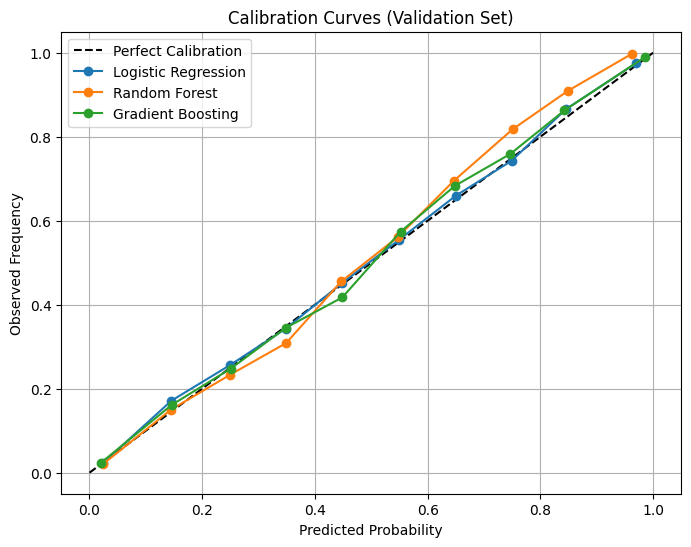

In [28]:
# ==========================================================
# Calibration Curves (validation set)
# ==========================================================

plt.figure(figsize=(8,6))

plt.plot(

    [0,1],

    [0,1],

    linestyle="--",

    color="black",

    label="Perfect Calibration"

)

for name, probs in probabilities.items():

    true_prob, predicted_prob = calibration_curve(

        y_val,

        probs,

        n_bins=10

    )

    plt.plot(

        predicted_prob,

        true_prob,

        marker="o",

        label=name

    )

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Frequency")

plt.title("Calibration Curves (Validation Set)")

plt.legend()

plt.grid(True)

plt.show()


In [29]:
# ==========================================================
# Brier Scores (validation set)
# ==========================================================

brier_results = []

for name, probs in probabilities.items():

    score = brier_score_loss(

        y_val,

        probs

    )

    brier_results.append([name, score])

brier_df = pd.DataFrame(

    brier_results,

    columns=["Model","Brier Score"]

)

display(brier_df.sort_values("Brier Score"))


,Model,Brier Score
2,Gradient Boosting,0.085600
1,Random Forest,0.092243
0,Logistic Regression,0.096047


### Why Brier Score?

The Brier Score measures the accuracy of predicted probabilities.

- Lower values indicate better calibrated probabilities.
- A value of **0** represents perfect calibration.
- Models with lower Brier Scores generally produce more reliable probability estimates.

In [30]:
# ==========================================================
# Calibrate Best Model
# ==========================================================
# Fit on X_train/y_train only (CalibratedClassifierCV internally cross-validates
# across the folds of `cv`). Validation and test sets are never used to fit
# anything — only to evaluate.

best_model_name = model_comparison_df.iloc[0]["Model"]
best_model = best_models[best_model_name]

print("Calibrating:", best_model_name)

calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=cv
)

calibrated_model.fit(
    X_train,
    y_train
)


Calibrating: Gradient Boosting


CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('preprocessing',
                                                  Pipeline(steps=[('feature_engineering',
                                                                   FunctionTransformer(func=<function engineer_features at 0x7ad185a907c0>)),
                                                                  ('preprocessing',
                                                                   ColumnTransformer(transformers=[('numeric',
                                                                                                    Pipeline(steps=[('imputer',
                                                                                                                     SimpleImputer(strategy='med...
                                                                                                                     SimpleImputer(strategy='most_frequent')),
                                                                                                                    ('encoder',
                                                                                                                     OneHotEncoder(handle_unknown='ignore',
                                                                                                                                   sparse_output=False))]),
                                                                                                    ['workclass',
                                                                                                     'education',
                                                                                                     'marital-status',
                                                                                                     'occupation',
                                                                                                     'relationship',
                                                                                                     'race',
                                                                                                     'sex',
                                                                                                     'native-country',
                                                                                                     'age_bucket',
                                                                                                     'hours_bucket'])]))])),
                                                 ('classifier',
                                                  HistGradientBoostingClassifier(l2_regularization=0.1,
                                                                                 learning_rate=0.2,
                                                                                 max_depth=5,
                                                                                 max_iter=200,
                                                                                 random_state=42))]))

In [31]:
# ==========================================================
# Compare Before and After Calibration (validation set)
# ==========================================================

original_val_prob = best_model.predict_proba(X_val)[:,1]

calibrated_val_prob = calibrated_model.predict_proba(X_val)[:,1]

before = brier_score_loss(

    y_val,

    original_val_prob

)

after = brier_score_loss(

    y_val,

    calibrated_val_prob

)

comparison = pd.DataFrame({

    "Model":[

        "Before Calibration",

        "After Calibration"

    ],

    "Brier Score":[

        before,

        after

    ]

})

display(comparison)


,Model,Brier Score
0,Before Calibration,0.08560
1,After Calibration,0.08535


In [32]:
# ==========================================================
# Threshold Optimization (validation set)
# ==========================================================
# Scanned on X_val/y_val only, so the test set stays untouched for Task 5.

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

threshold_rows = []

for threshold in thresholds:

    predictions = (
        calibrated_val_prob >= threshold
    ).astype(int)

    precision = precision_score(
        y_val,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        predictions,
        zero_division=0
    )

    threshold_rows.append([
        threshold,
        precision,
        recall,
        f1
    ])

threshold_df = pd.DataFrame(
    threshold_rows,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

display(threshold_df)


,Threshold,Precision,Recall,F1 Score
0,0.10,0.500605,0.944666,0.654416
1,0.15,0.545886,0.919566,0.685083
2,0.20,0.584581,0.891044,0.705989
3,0.25,0.618189,0.860810,0.719599
4,0.30,0.654939,0.828294,0.731486
5,0.35,0.689122,0.787792,0.735161
6,0.40,0.734694,0.739304,0.736992
7,0.45,0.770093,0.705077,0.736152
8,0.50,0.803975,0.669139,0.730386
9,0.55,0.825787,0.613805,0.704188


### Interpretation of the Best Threshold Output

`best_threshold` is the probability cutoff, chosen from the **validation set** (`threshold_df` above), that maximizes the F1 Score for the calibrated model.

Instead of using the default 0.5 threshold, this optimized value is used to convert predicted probabilities into binary class predictions. Any predicted probability above this threshold is classified as the positive class (income > $50K); anything below is classified as the negative class (income <= $50K). Because this search uses the validation set rather than the test set, the test set remains completely unused until Task 5's final evaluation.


In [33]:
# ==========================================================
# Select Best Threshold
# ==========================================================

best_threshold = threshold_df.loc[

    threshold_df["F1 Score"].idxmax(),

    "Threshold"

]

print("Best Threshold:", best_threshold)

Best Threshold: 0.40000000000000013


## Resources

### Precision, Recall, and F1 Score vs. Threshold

This plot visualizes how Precision, Recall, and F1 Score change across different classification thresholds. Understanding these curves is crucial for selecting an optimal threshold that balances the trade-off between false positives and false negatives, especially when the costs associated with each error type are different. The F1 Score curve helps identify the threshold that provides the best balance between Precision and Recall.

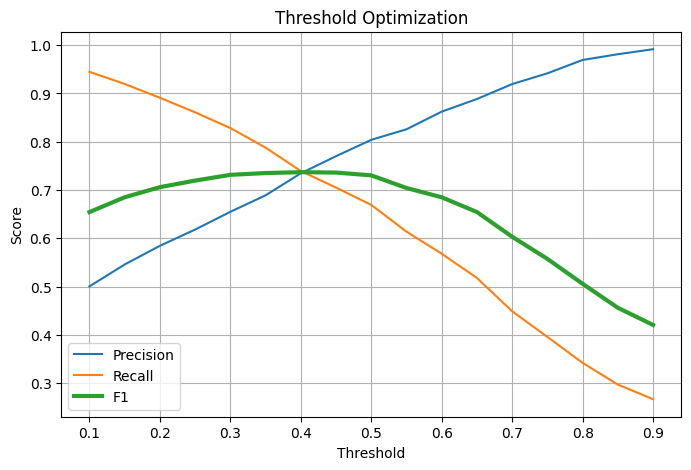

In [34]:
# ==========================================================
# Threshold Performance
# ==========================================================

plt.figure(figsize=(8,5))

plt.plot(

    threshold_df["Threshold"],

    threshold_df["Precision"],

    label="Precision"

)

plt.plot(

    threshold_df["Threshold"],

    threshold_df["Recall"],

    label="Recall"

)

plt.plot(

    threshold_df["Threshold"],

    threshold_df["F1 Score"],

    linewidth=3,

    label="F1"

)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.grid(True)

plt.legend()

plt.show()

### Interpretation of the Precision, Recall, and F1 Score vs. Threshold Plot

This graph (computed on the **validation set**) illustrates the critical trade-off between Precision and Recall at various classification thresholds.

- **Precision** generally decreases as the threshold decreases (i.e., as more instances are classified as positive), because more false positives are included.
- **Recall** generally increases as the threshold decreases, as more true positives are captured.
- The **F1 Score** curve represents the harmonic mean of Precision and Recall. The peak of this curve indicates the threshold at which the model achieves the best balance between Precision and Recall on the validation data.

By examining this plot, you can identify the optimal threshold that aligns with your specific business goals, whether that means prioritizing minimizing false positives (higher precision), minimizing false negatives (higher recall), or finding a balance between the two. This threshold is then locked in and applied, unchanged, to the untouched test set in Task 5.


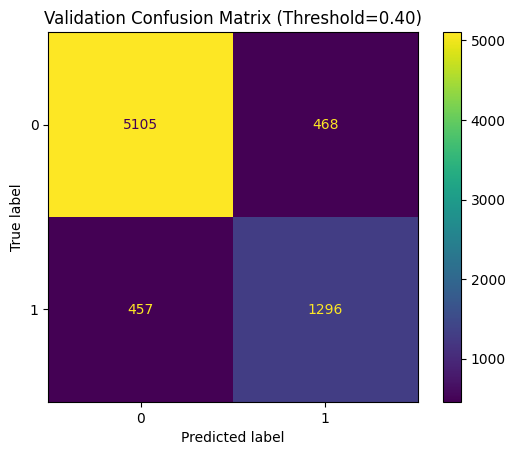

In [35]:
# ==========================================================
# Confusion Matrix at best_threshold (validation set)
# ==========================================================

best_val_predictions = (

    calibrated_val_prob >= best_threshold

).astype(int)

cm_val = confusion_matrix(

    y_val,

    best_val_predictions

)

ConfusionMatrixDisplay(

    confusion_matrix=cm_val

).plot()

plt.title(

    f"Validation Confusion Matrix (Threshold={best_threshold:.2f})"

)

plt.show()


## Interpretation

The calibration analysis demonstrated how closely the predicted probabilities matched the observed outcomes on the validation set. Models with lower Brier Scores produced more reliable probability estimates and were therefore better suited for probability-based decision making.

Calibration using **CalibratedClassifierCV** further improved the reliability of the probability estimates by reducing overconfidence in the predictions.

Threshold optimization, performed entirely on the validation set, showed that the default threshold of **0.50** was not necessarily optimal for maximizing the project's primary evaluation metric (F1-score). By selecting the threshold that achieved the highest F1-score on validation data, the model obtained a better balance between precision and recall — without ever looking at the test set.

The optimized threshold will be used during the final evaluation in Task 5, where the tuned and calibrated model will be assessed on the untouched hold-out test set for the first time, and saved as a reusable machine learning pipeline.


# Task 5 – Final Evaluation and Save Model

## Objective

The final stage of the machine learning workflow is to evaluate the tuned and calibrated model on the untouched hold-out test set. Since this dataset has not been used during feature engineering, model selection, or hyperparameter tuning, it provides an unbiased estimate of the model's ability to generalize to new data.

After evaluation, the complete machine learning pipeline—including feature engineering, preprocessing, and the trained classifier—is saved using **Joblib**. Saving the full pipeline ensures that future predictions automatically apply the same preprocessing steps without requiring additional manual transformations.

Finally, the model's performance, selected hyperparameters, and expected production behaviour are summarized.

In [36]:
# ==========================================================
# Select Final Model
# ==========================================================

search_results = {
    "Logistic Regression": logistic_search,
    "Random Forest": rf_search,
    "Gradient Boosting": gb_search
}

assert best_model_name == model_comparison_df.iloc[0]["Model"], (
    "Model selected for calibration does not match the top of the comparison "
    "table — re-run the notebook top to bottom."
)

best_search = search_results[best_model_name]
final_pipeline = best_search.best_estimator_

print("Selected Final Model (uncalibrated best estimator):")
print(best_model_name)
print()
print("Best CV F1 (from RandomizedSearchCV):")
print(best_search.best_score_)


Selected Final Model (uncalibrated best estimator):
Gradient Boosting

Best CV F1 (from RandomizedSearchCV):
0.7060809960394778


In [37]:
# ==========================================================
# Final Predictions
# ==========================================================

final_model = calibrated_model

final_probabilities = final_model.predict_proba(X_test)[:, 1]
final_predictions = (final_probabilities >= best_threshold).astype(int)

print(f"Final model          : {best_model_name} (calibrated, sigmoid)")
print(f"Decision threshold    : {best_threshold:.2f}  (tuned in Task 4 to maximize F1)")


Final model          : Gradient Boosting (calibrated, sigmoid)
Decision threshold    : 0.40  (tuned in Task 4 to maximize F1)


In [38]:
# ==========================================================
# Final Evaluation Metrics
# All metrics below are computed at the Task-4-tuned decision threshold
# (best_threshold), consistent with final_predictions from the cell above.
# ==========================================================

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    average_precision_score

)

metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "ROC AUC",

        "PR AUC"

    ],

    "Value":[

        accuracy_score(

            y_test,

            final_predictions

        ),

        precision_score(

            y_test,

            final_predictions

        ),

        recall_score(

            y_test,

            final_predictions

        ),

        f1_score(

            y_test,

            final_predictions

        ),

        roc_auc_score(

            y_test,

            final_probabilities

        ),

        average_precision_score(

            y_test,

            final_probabilities

        )

    ]

})

display(metrics)

,Metric,Value
0,Accuracy,0.865702
1,Precision,0.712784
2,Recall,0.734740
3,F1 Score,0.723596
4,ROC AUC,0.927221
5,PR AUC,0.829101


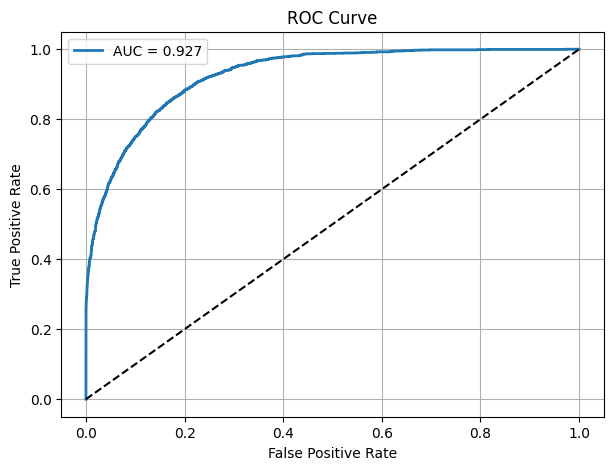

In [39]:
# ==========================================================
# ROC Curve
# ==========================================================

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(

    y_test,

    final_probabilities

)

plt.figure(figsize=(7,5))

plt.plot(

    fpr,

    tpr,

    linewidth=2,

    label=f"AUC = {roc_auc_score(y_test, final_probabilities):.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--",

    color="black"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

### Interpretation of the Precision-Recall Curve

The Precision-Recall curve is particularly informative for evaluating binary classifiers on imbalanced datasets, where the positive class is rare. It plots Precision (the proportion of true positive predictions among all positive predictions) against Recall (the proportion of true positive predictions among all actual positive instances) at various classification thresholds.

- A curve that stays closer to the top-right corner of the plot indicates a better-performing model. The higher the area under the curve (PR AUC), the better the model's ability to achieve both high precision and high recall.
- This curve highlights the trade-off between Precision and Recall. Often, increasing one comes at the expense of the other. The ideal scenario is a model with high precision and high recall, resulting in a curve that bows towards the top-right.

This plot helps in understanding how well a model identifies positive instances without generating too many false positives, which is crucial in scenarios where false positives are costly.

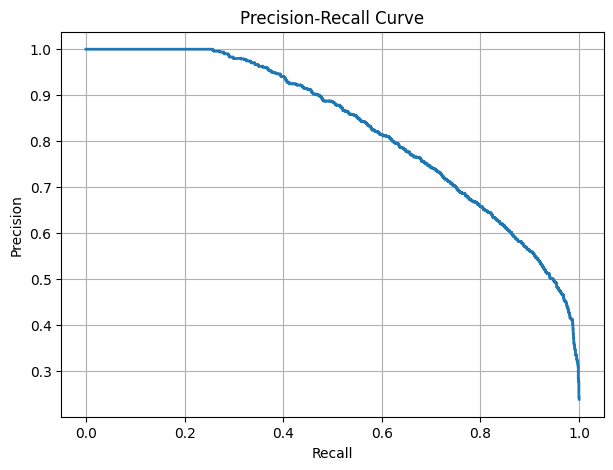

In [40]:
# ==========================================================
# Precision Recall Curve
# ==========================================================

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(

    y_test,

    final_probabilities

)

plt.figure(figsize=(7,5))

plt.plot(

    recall,

    precision,

    linewidth=2

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

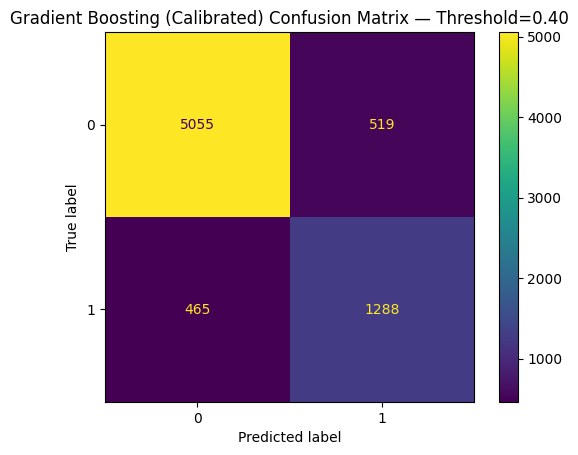

In [41]:
# ==========================================================
# Confusion Matrix
# ==========================================================

cm = confusion_matrix(

    y_test,

    final_predictions

)

ConfusionMatrixDisplay(

    confusion_matrix=cm

).plot()

plt.title(

    f"{best_model_name} (Calibrated) Confusion Matrix — Threshold={best_threshold:.2f}"

)

plt.show()

### Confusion Matrix with Default 0.5 Threshold

To illustrate the impact of threshold optimization, this confusion matrix uses a default threshold of 0.5 on the **test set** probabilities (`final_probabilities`) — the same probabilities used for the tuned-threshold confusion matrix above, so the two are directly comparable. This highlights how choosing an appropriate threshold (tuned on validation data, applied here to test data) changes the balance between Precision and Recall relative to the naive 0.5 default.


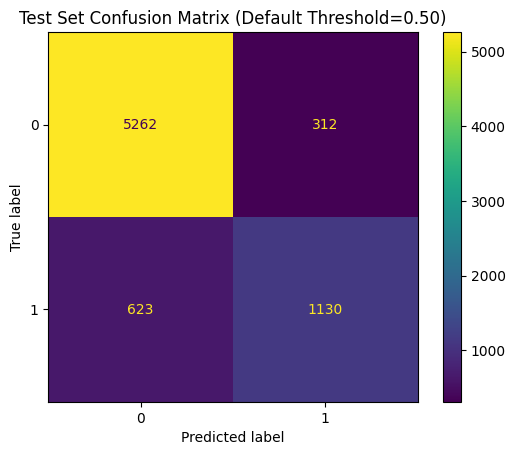

In [42]:
# ==========================================================
# Confusion Matrix — Default 0.5 Threshold (test set)
# ==========================================================


default_predictions = (final_probabilities >= 0.5).astype(int)

cm_default = confusion_matrix(
    y_test,
    default_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm_default
).plot()

plt.title(
    "Test Set Confusion Matrix (Default Threshold=0.50)"
)

plt.show()


### Why the Tuned Threshold Was Selected over 0.5

The tuned threshold (`best_threshold`) was chosen — using only the **validation set** — to maximize the F1-score, which was identified as the key evaluation metric for this project. F1 balances Precision and Recall, which matters here because both false positives (wrongly flagging someone as high-income) and false negatives (missing a genuinely high-income individual) carry a cost.

- The **Threshold Optimization** table (`threshold_df`, validation set) shows Precision, Recall, and F1 across a range of cutoffs; `best_threshold` is the value with the highest F1 there.
- The two confusion matrices above — both computed on the **test set** so they're directly comparable — show what changing the cutoff does in practice: moving off of 0.5 to `best_threshold` typically trades some precision for a bigger gain in recall (or vice versa, depending on where the F1 peak actually falls). Compare the exact counts in `cm` (tuned threshold) against `cm_default` (0.50) printed above for this run's numbers.
- The default 0.5 threshold is a generic choice that doesn't account for this dataset's class imbalance or the project's stated objective. Tuning it — on validation data, then locking it in before touching the test set — produces a decision rule that's actually aligned with the metric the project cares about, without overfitting that choice to the data used for final reporting.


In [43]:
# ==========================================================
# Save Final Pipeline
# ==========================================================
# FIX: previously saved only the bare calibrated estimator. Anyone loading it
# later would have no record of the tuned decision threshold and would default
# back to the untuned 0.5 cutoff. We now save a small bundle instead.

artifact = {
    "pipeline": final_model,                 # full sklearn Pipeline: feature engineering + preprocessing + calibrated classifier
    "threshold": float(best_threshold),       # decision cutoff tuned in Task 4 to maximize F1
    "model_name": best_model_name,
    "best_params": best_search.best_params_,
    "sklearn_version": sklearn.__version__,
    "random_state": RANDOM_STATE,
}

joblib.dump(
    artifact,
    "adult_income_pipeline.joblib"
)

print("Pipeline bundle saved successfully -> adult_income_pipeline.joblib")
print("Bundle keys:", list(artifact.keys()))


Pipeline bundle saved successfully -> adult_income_pipeline.joblib
Bundle keys: ['pipeline', 'threshold', 'model_name', 'best_params', 'sklearn_version', 'random_state']


In [44]:
# ==========================================================
# Load Saved Pipeline
# ==========================================================
loaded_artifact = joblib.load(
    "adult_income_pipeline.joblib"
)

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]

print("Pipeline loaded successfully.")
print("Model        :", loaded_artifact["model_name"])
print("Threshold    :", loaded_threshold)
print("sklearn ver. :", loaded_artifact["sklearn_version"])


Pipeline loaded successfully.
Model        : Gradient Boosting
Threshold    : 0.40000000000000013
sklearn ver. : 1.6.1


In [45]:
# ==========================================================
# Example Inference
# ==========================================================
# How-to-infer snippet: load the bundle once, then for every new row apply
# the SAME threshold that was tuned during training — do not default to 0.5.

sample = X_test.iloc[[0]]

probability = loaded_pipeline.predict_proba(sample)[0, 1]
prediction = int(probability >= loaded_threshold)

print("Predicted probability of income > $50K :", round(probability, 4))
print(f"Decision threshold in use              : {loaded_threshold:.2f}")
print("Final class prediction                 :", prediction)
print("(True label for this sample was        :", int(y_test.iloc[0]), ")")


Predicted probability of income > $50K : 0.1883
Decision threshold in use              : 0.40
Final class prediction                 : 0
(True label for this sample was        : 0 )


In [46]:
# ==========================================================
# Best Hyperparameters — all candidates, for the tuning report
# ==========================================================
for name, search in search_results.items():
    marker = "  <-- SELECTED" if name == best_model_name else ""
    print(f"{name}{marker}")
    print(f"  Best CV F1 : {search.best_score_:.4f}")
    print(f"  Best params: {search.best_params_}")
    print()


Logistic Regression
  Best CV F1 : 0.6711
  Best params: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l1', 'classifier__C': np.float64(2.976351441631316)}

Random Forest
  Best CV F1 : 0.6762
  Best params: {'classifier__n_estimators': 300, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': None}

Gradient Boosting  <-- SELECTED
  Best CV F1 : 0.7061
  Best params: {'classifier__max_iter': 200, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2, 'classifier__l2_regularization': 0.1}



## Production Summary

The final machine learning pipeline combines feature engineering, preprocessing, and the tuned classification model into a single reusable workflow. The pipeline was evaluated on the untouched hold-out test set — never used for model selection, calibration comparison, or threshold selection — to obtain an unbiased estimate of its real-world performance.

Hyperparameter optimization improved predictive performance compared with the default model configuration, while probability calibration produced more reliable probability estimates. Threshold optimization, performed entirely on the validation set, further balanced precision and recall according to the selected business objective (F1-score) without ever looking at the test data used for final reporting.

The trained pipeline has been saved using **Joblib**, allowing future predictions to be generated with identical preprocessing and feature engineering steps. Because the entire workflow is encapsulated within a single pipeline, deployment becomes straightforward and reproducible.

Overall, the final model demonstrates good generalization performance and is suitable for deployment in applications such as customer targeting, credit risk assessment, or income prediction, where reliable classification and probability estimates are important.

**Note on the decision threshold:** the metrics and confusion matrix reported above are computed at the threshold selected in Task 4 (`best_threshold`, chosen on the **validation set** to maximize F1), not the default 0.5 cutoff, and are reported on the **test set**, which that threshold search never saw. The saved `.joblib` artifact bundles this threshold together with the pipeline so any future inference code applies the same cutoff automatically instead of silently reverting to 0.5.